In [1]:
import torch
import torch.nn as nn
import torchvision
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
from torchinfo import summary
import os

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using {device}')

Using cuda


In [3]:
if not os.path.exists('./data'):
    os.makedirs('./data')

In [4]:
data_train = torchvision.datasets.MNIST('./data',
        download=True,train=True,transform=ToTensor())
data_test = torchvision.datasets.MNIST('./data',
        download=True,train=False,transform=ToTensor())

In [5]:
def plot_results(hist):
    plt.figure(figsize=(15,5))
    plt.subplot(121)
    plt.plot(hist['train_acc'], label='Training acc')
    plt.plot(hist['val_acc'], label='Validation acc')
    plt.legend()
    plt.subplot(122)
    plt.plot(hist['train_loss'], label='Training loss')
    plt.plot(hist['val_loss'], label='Validation loss')
    plt.legend()

In [6]:
train_loader = torch.utils.data.DataLoader(data_train, batch_size = 64)
test_loader = torch.utils.data.DataLoader(data_test, batch_size = 64)

In [7]:
def train_epoch(net, dataloader, lr = 0.01, optimizer = None, loss_fn = nn.NLLLoss()):
    optimizer = optimizer or torch.optim.Adam(net.parameters(), lr = lr)
    net.train()
    total_loss, acc, count = 0,0,0
    for features, labels in dataloader:
        features = features.to(device=device)
        labels = labels.to(device=device)
        optimizer.zero_grad()
        out = net(features)
        loss = loss_fn(out, labels) #cross_entropy(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss
        _, predicted = torch.max(out, 1)
        acc += (predicted == labels).sum()
        count += len(labels)
    return total_loss.item()/count, acc.item()/count

In [8]:
def validate(net, dataloader, loss_fn=nn.NLLLoss()):
    net.eval()
    count, acc, loss = 0,0,0
    with torch.no_grad():
        for features, labels in dataloader:
            features = features.to(device)
            labels = labels.to(device)
            out = net(features)
            loss += loss_fn(out, labels)
            pred = torch.max(out, 1)[1]
            acc += (pred==labels).sum()
            count += len(labels)
    return loss.item()/count, acc.item()/count

In [9]:
def train(net, train_loader, test_loader, optimizer = None, lr = 0.01, epochs = 10, loss_fn = nn.NLLLoss()):
    optimizer = optimizer or torch.optim.Adam(net.parameters(), lr = lr)
    res = {'train_loss' : [], 'train_acc' : [], 'val_loss' : [], 'val_acc' : []}
    for ep in range(epochs):
        tl, ta = train_epoch(net, train_loader, optimizer = optimizer, lr = lr, loss_fn=loss_fn)
        vl, va = validate(net, test_loader, loss_fn=loss_fn)
        print(f'Epoch {ep:2}, Train acc={ta:.3f}, Val acc={va:.3f}, Train loss={tl:.3f}, Val loss={vl:.3f}')
        res['train_loss'].append(tl)
        res['train_acc'].append(ta)
        res['val_loss'].append(vl)
        res['val_acc'].append(va)
    return res

In [10]:
from torch.nn.functional import relu, log_softmax

class MyNet(nn.Module):
    def __init__(self):
        super(MyNet, self).__init__()
        self.flatten = nn.Flatten()
        self.hidden = nn.Linear(784, 100)
        self.out = nn.Linear(100, 10)
    
    def forward(self, x):
        x = self.flatten(x)
        x = self.hidden(x)
        x = relu(x)
        x = self.out(x)
        x = log_softmax(x, dim=1)
        return x
net = MyNet().to(device)

summary(net, input_size=(1,28,28), device = device)

Layer (type:depth-idx)                   Output Shape              Param #
MyNet                                    [1, 10]                   --
├─Flatten: 1-1                           [1, 784]                  --
├─Linear: 1-2                            [1, 100]                  78,500
├─Linear: 1-3                            [1, 10]                   1,010
Total params: 79,510
Trainable params: 79,510
Non-trainable params: 0
Total mult-adds (M): 0.08
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.32
Estimated Total Size (MB): 0.32

Epoch  0, Train acc=0.926, Val acc=0.946, Train loss=0.004, Val loss=0.003
Epoch  1, Train acc=0.960, Val acc=0.958, Train loss=0.002, Val loss=0.003
Epoch  2, Train acc=0.965, Val acc=0.960, Train loss=0.002, Val loss=0.003
Epoch  3, Train acc=0.970, Val acc=0.960, Train loss=0.002, Val loss=0.003
Epoch  4, Train acc=0.971, Val acc=0.961, Train loss=0.002, Val loss=0.003


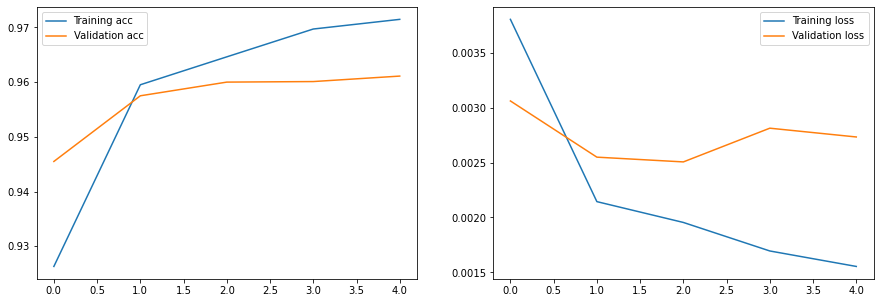

In [11]:
hist = train(net, train_loader, test_loader, epochs = 5)
plot_results(hist)

In [12]:
# save the model
torch.save(net.state_dict(), './data/model.pth')

In [13]:
model = MyNet()
model.load_state_dict(torch.load('./data/model.pth'))

<All keys matched successfully>

In [14]:
model.eval()

MyNet(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (hidden): Linear(in_features=784, out_features=100, bias=True)
  (out): Linear(in_features=100, out_features=10, bias=True)
)